# Finding the Best Neighborhood in Pittsburgh
## CMPINF 0010 — Final Project Combined Notebook
### Group 8

**Team Members:**
- Kevin Harned
- Sadia Azizi

**Date:** April 2026

## Introduction

For this project, our group set out to answer the question: *What is the best neighborhood in Pittsburgh?*

Of course, "best" is subjective, which means it depends on what you value. Our approach was to break the question into measurable sub-metrics, each capturing a different dimension of neighborhood quality. We then combined those sub-metrics into a single score to produce an overall ranking.

We chose to focus on two factors:
1. **Higher Education Rate** (Kevin) — the percentage of a neighborhood's population enrolled in college or graduate school, using ACS school enrollment data from WPRDC.
2. **Green Space Availability** (Sadia) — the number of parks and green spaces in each neighborhood, using the WPRDC green spaces dataset.

Our reasoning is that a great neighborhood should offer both intellectual opportunity and access to nature. A place where people are pursuing education and can also enjoy parks and outdoor areas is likely to have a high quality of life. In my opinionm, it is a good mix of learning and also nature, it is a good balance.

Before settling on these metrics, we considered alternatives. Kevin initially thought about using overall school enrollment rate, but decided against it because it wouldn't distinguish between elementary students and college students. He also considered graduate school rate alone, but that would only highlight neighborhoods immediately adjacent to Pitt and CMU. Sadia considered normalizing green space counts by population or area, but the raw count still provides a clear and interpretable measure of how many outdoor options are available to residents.

In this notebook, we load the results from our individual analyses, normalize them to a common scale, combine them into one metric, and determine the best neighborhood in Pittsburgh.

## Step one: Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# this is chart styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

## Step 2: Load the Individual Sub-Metric Data

Kevin's notebook exported a CSV with each neighborhood's higher education rate and rank. Sadia's analysis counted green spaces per neighborhood. We load both datasets here.

In [2]:
# Load my (Kevin) higher education metric
education_df = pd.read_csv('higher_education_metric.csv')
print(f"Education data: {education_df.shape[0]} neighborhoods")
education_df.head()

Education data: 91 neighborhoods


,Neighborhood,Higher_Ed_Rate_Pct,Higher_Ed_Rank
0,Central Oakland,78.573809,1
1,North Oakland,72.412050,2
2,Bluff,56.585441,3
3,Terrace Village,50.215332,4
4,South Oakland,47.627119,5


In [3]:
# Load Sadia's green spaces dataset and count per neighborhood in here
green_raw = pd.read_csv('green_spaces.csv')
green_counts = green_raw['neighborhood'].value_counts().reset_index()
green_counts.columns = ['Neighborhood', 'Green_Space_Count']
print(f"Green space data: {green_counts.shape[0]} neighborhoods")
green_counts.head()

Green space data: 73 neighborhoods


,Neighborhood,Green_Space_Count
0,East Liberty,12
1,Central Business District,10
2,Beechview,8
3,South Side Slopes,7
4,Point Breeze,7


## Step three, Merge the Two Datasets

We merge on the neighborhood name. Some neighborhoods may appear in one dataset but not the other. For example, a neighborhood with zero green spaces won't appear in Sadia's data. We use an outer merge so we don't lose any neighborhoods, and fill missing green space counts with 0.

In [4]:
# Merge the two datasets on Neighborhood name
merged = pd.merge(
    education_df, 
    green_counts, 
    on='Neighborhood', 
    how='outer'
)

# Fill missing values, what this means is neighborhoods not in green spaces data have 0 parks
merged['Green_Space_Count'] = merged['Green_Space_Count'].fillna(0)

# Fill missing education values, meaning neighborhoods not in education data, with 0
merged['Higher_Ed_Rate_Pct'] = merged['Higher_Ed_Rate_Pct'].fillna(0)

print(f"Merged dataset: {merged.shape[0]} neighborhoods")
merged.head(10)

Merged dataset: 91 neighborhoods


,Neighborhood,Higher_Ed_Rate_Pct,Higher_Ed_Rank,Green_Space_Count
0,Allegheny Center,15.741391,17,2.0
1,Allegheny West,8.446866,38,0.0
2,Allentown,7.896825,43,2.0
3,Arlington,8.700322,36,1.0
4,Arlington Heights,9.049774,35,0.0
5,Banksville,3.168008,80,2.0
6,Bedford Dwellings,1.866252,85,1.0
7,Beechview,9.630362,33,8.0
8,Beltzhoover,9.073959,34,3.0
9,Bloomfield,19.923902,14,3.0


## Step 4: Normalize Both Metrics

Our two sub-metrics are on completely different scales. What I mean by this is higher education rate is a percentage (0–79%), while green space count is a raw number (0–12). To combine them fairly, we normalize both to a 0–100 scale using min-max normalization:

$$\text{normalized} = \frac{\text{value} - \text{min}}{\text{max} - \text{min}} \times 100$$

This way, the neighborhood with the highest value on each metric gets a score of 100, and the lowest gets 0.

In [5]:
# Min-max normalization to 0-100 scale

# Normalize higher education rate
ed_min = merged['Higher_Ed_Rate_Pct'].min()
ed_max = merged['Higher_Ed_Rate_Pct'].max()
merged['Education_Score'] = ((merged['Higher_Ed_Rate_Pct'] - ed_min) / (ed_max - ed_min)) * 100

# Normalize green space count
gs_min = merged['Green_Space_Count'].min()
gs_max = merged['Green_Space_Count'].max()
merged['GreenSpace_Score'] = ((merged['Green_Space_Count'] - gs_min) / (gs_max - gs_min)) * 100

print("Normalization complete")
print(f"  Education Score range: {merged['Education_Score'].min():.1f} to {merged['Education_Score'].max():.1f}")
print(f"  Green Space Score range: {merged['GreenSpace_Score'].min():.1f} to {merged['GreenSpace_Score'].max():.1f}")

Normalization complete
  Education Score range: 0.0 to 100.0
  Green Space Score range: 0.0 to 100.0


## Step 5: Calculate the Combined Score

We weight both metrics equally (50/50) since we believe education and green space access are both important contributors to neighborhood quality. The combined score is simply the average of the two normalized scores.

In [6]:
# Combined score: equal weight (50% education, 50% green space), a fair split
merged['Combined_Score'] = (merged['Education_Score'] + merged['GreenSpace_Score']) / 2

# Rank by combined score, 
merged = merged.sort_values('Combined_Score', ascending=False).reset_index(drop=True)
merged['Combined_Rank'] = range(1, len(merged) + 1)

print("Combined ranking complete\n")

Combined ranking complete



## Step 6: The Results

In [7]:
# Display the top 15 neighborhoods in pittsburgh
print("TOP 15 NEIGHBORHOODS IN PITTSBURGH\n")
top_15 = merged[['Combined_Rank', 'Neighborhood', 'Combined_Score', 
                  'Education_Score', 'GreenSpace_Score',
                  'Higher_Ed_Rate_Pct', 'Green_Space_Count']].head(15)
top_15

TOP 15 NEIGHBORHOODS IN PITTSBURGH



,Combined_Rank,Neighborhood,Combined_Score,Education_Score,GreenSpace_Score,Higher_Ed_Rate_Pct,Green_Space_Count
0,1,Central Business District,67.347214,51.361095,83.333333,40.356369,10.0
1,2,Central Oakland,66.666667,100.000000,33.333333,78.573809,4.0
2,3,East Liberty,56.970267,13.940534,100.000000,10.953608,12.0
3,4,South Oakland,51.140582,60.614497,41.666667,47.627119,5.0
4,5,North Oakland,50.245666,92.157999,8.333333,72.412050,1.0
5,6,South Side Flats,43.916194,37.832389,50.000000,29.726349,6.0
6,7,Terrace Village,40.287576,63.908486,16.666667,50.215332,2.0
7,8,Bluff,40.174493,72.015653,8.333333,56.585441,1.0
8,9,South Side Slopes,39.881885,21.430436,58.333333,16.838710,7.0
9,10,Beechview,39.461560,12.256453,66.666667,9.630362,8.0


In [8]:
# Display the bottom 10 neighborhoods in pittsburgh here
print("BOTTOM 10 NEIGHBORHOODS\n")
bottom_10 = merged[['Combined_Rank', 'Neighborhood', 'Combined_Score', 
                     'Education_Score', 'GreenSpace_Score',
                     'Higher_Ed_Rate_Pct', 'Green_Space_Count']].tail(10)
bottom_10

BOTTOM 10 NEIGHBORHOODS



,Combined_Rank,Neighborhood,Combined_Score,Education_Score,GreenSpace_Score,Higher_Ed_Rate_Pct,Green_Space_Count
81,82,Glen Hazel,4.138077,8.276155,0.0,6.502890,0.0
82,83,Overbrook,3.797259,7.594519,0.0,5.967302,0.0
83,84,Mount Oliver Borough,3.536303,7.072605,0.0,5.557215,0.0
84,85,California-Kirkbride,3.421206,6.842412,0.0,5.376344,0.0
85,86,Knoxville,3.401395,6.802790,0.0,5.345212,0.0
86,87,Chartiers City,3.181722,6.363444,0.0,5.000000,0.0
87,88,Summer Hill,2.540860,5.081721,0.0,3.992902,0.0
88,89,Mt. Oliver,1.166631,2.333263,0.0,1.833333,0.0
89,90,Chateau,0.000000,0.000000,0.0,0.000000,0.0
90,91,St. Clair,0.000000,0.000000,0.0,0.000000,0.0


In [9]:
# Identify the best neighborhood
best = merged.iloc[0]
print(f"THE BEST NEIGHBORHOOD IN PITTSBURGH IS: {best['Neighborhood']}")
print(f"  Combined Score: {best['Combined_Score']:.2f}")
print(f"  Education Score: {best['Education_Score']:.2f} (Higher Ed Rate: {best['Higher_Ed_Rate_Pct']:.1f}%)")
print(f"  Green Space Score: {best['GreenSpace_Score']:.2f} (Green Spaces: {int(best['Green_Space_Count'])})")

THE BEST NEIGHBORHOOD IN PITTSBURGH IS: Central Business District
  Combined Score: 67.35
  Education Score: 51.36 (Higher Ed Rate: 40.4%)
  Green Space Score: 83.33 (Green Spaces: 10)


## Step 7: The Visualizations

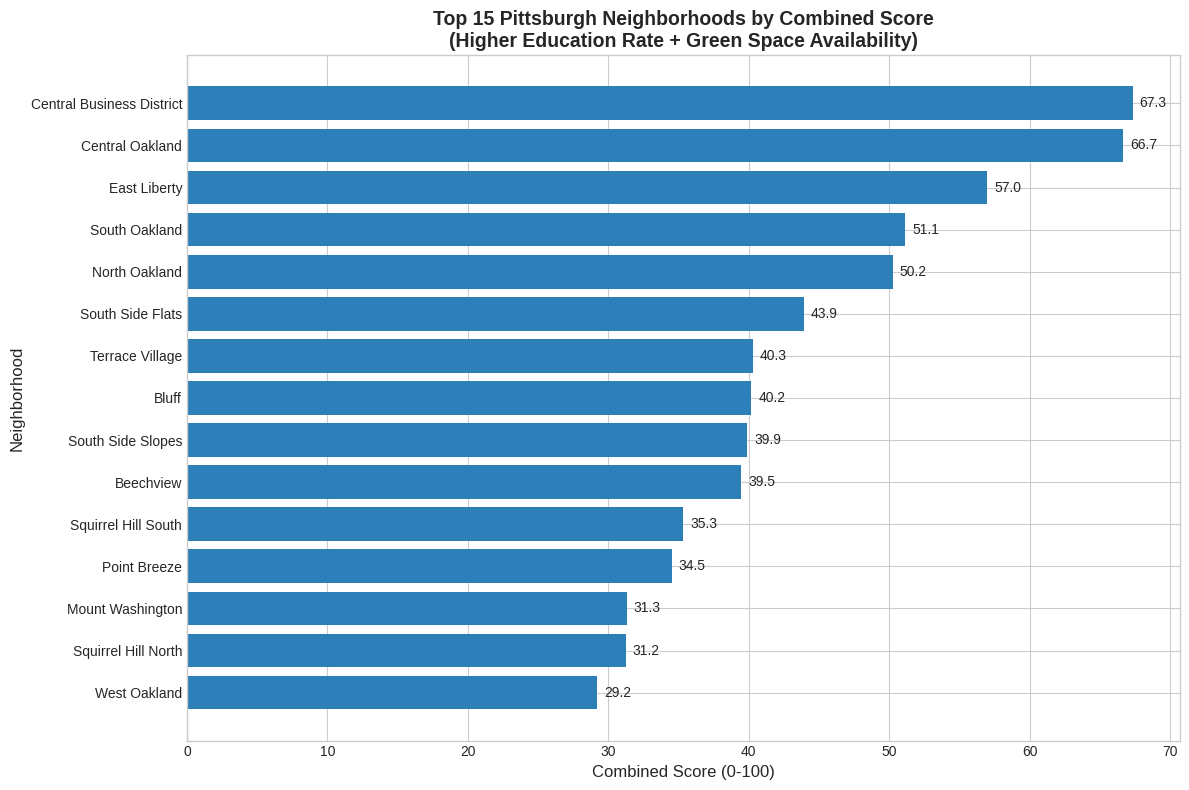

In [10]:
# Visualization 1: Top 15 neighborhoods by combined score
top_15_viz = merged.head(15).copy()

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(top_15_viz['Neighborhood'], top_15_viz['Combined_Score'], color='#2c7fb8')
ax.set_xlabel('Combined Score (0-100)', fontsize=12)
ax.set_ylabel('Neighborhood', fontsize=12)
ax.set_title('Top 15 Pittsburgh Neighborhoods by Combined Score\n(Higher Education Rate + Green Space Availability)', 
             fontsize=14, fontweight='bold')
ax.invert_yaxis()

for bar, val in zip(bars, top_15_viz['Combined_Score']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}', 
            va='center', fontsize=10)

plt.tight_layout()
plt.show()

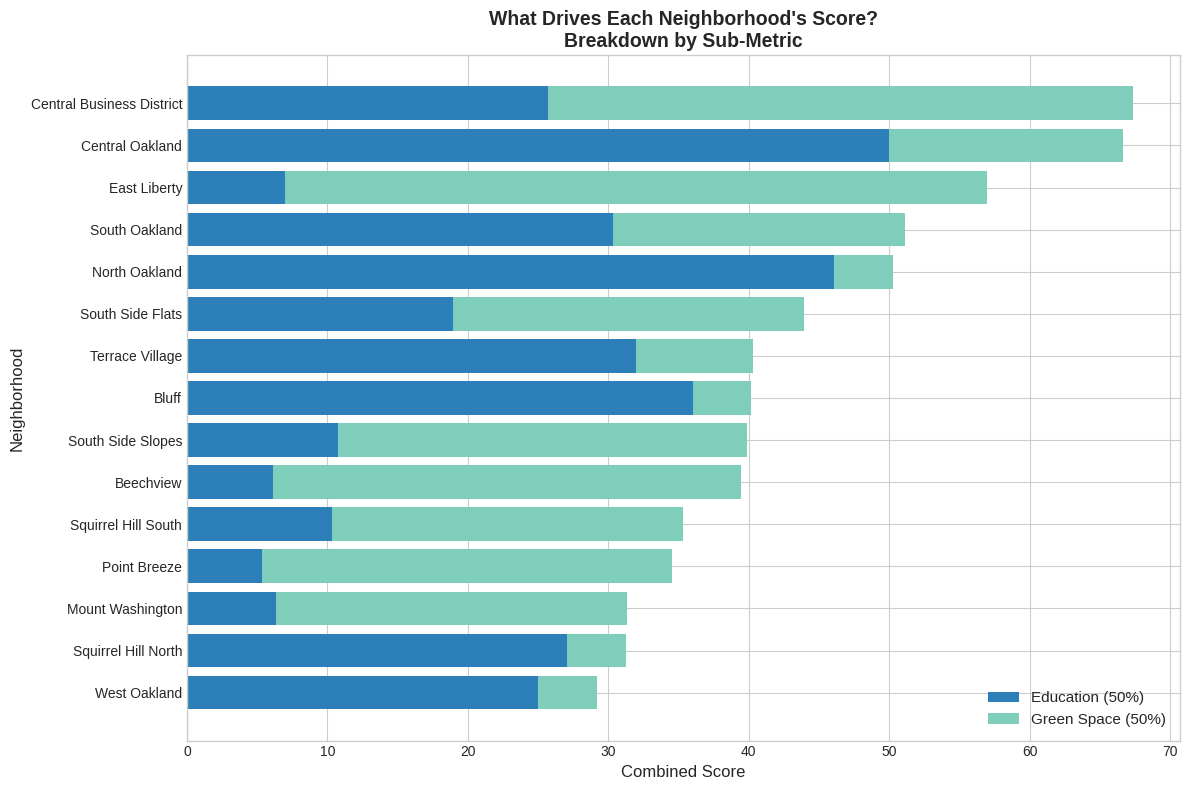

In [11]:
# Visualization 2: Stacked bar chart showing contribution of each submetric
top_15_viz = merged.head(15).copy()

fig, ax = plt.subplots(figsize=(12, 8))

# Plot education score first, then stack green space on top
bars1 = ax.barh(top_15_viz['Neighborhood'], top_15_viz['Education_Score'] / 2, 
                color='#2c7fb8', label='Education (50%)')
bars2 = ax.barh(top_15_viz['Neighborhood'], top_15_viz['GreenSpace_Score'] / 2, 
                left=top_15_viz['Education_Score'] / 2,
                color='#7fcdbb', label='Green Space (50%)')

ax.set_xlabel('Combined Score', fontsize=12)
ax.set_ylabel('Neighborhood', fontsize=12)
ax.set_title('What Drives Each Neighborhood\'s Score?\nBreakdown by Sub-Metric', 
             fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

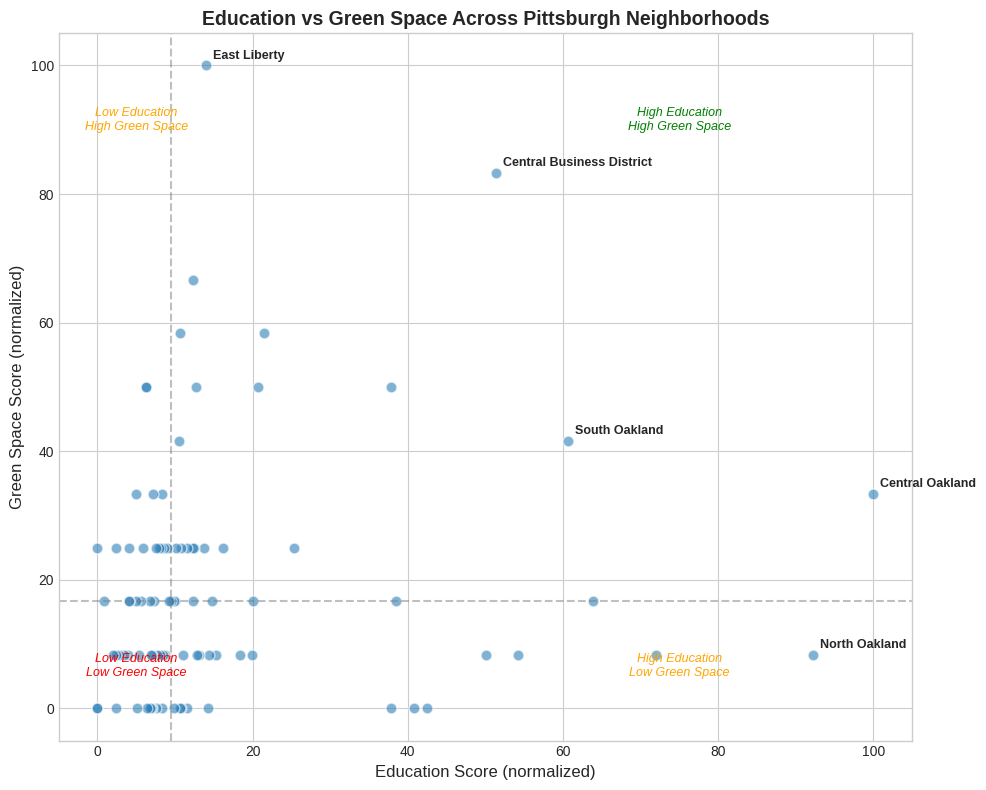

In [12]:
# Visualization 3: Scatter plot — Education Score vs Green Space Score
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(merged['Education_Score'], merged['GreenSpace_Score'], 
           s=60, alpha=0.6, color='#2c7fb8', edgecolors='white')

# Label the top 5 neighborhoods
for i in range(5):
    row = merged.iloc[i]
    ax.annotate(row['Neighborhood'], 
                (row['Education_Score'], row['GreenSpace_Score']),
                fontsize=9, fontweight='bold',
                xytext=(5, 5), textcoords='offset points')

ax.set_xlabel('Education Score (normalized)', fontsize=12)
ax.set_ylabel('Green Space Score (normalized)', fontsize=12)
ax.set_title('Education vs Green Space Across Pittsburgh Neighborhoods', 
             fontsize=14, fontweight='bold')

# Add quadrant lines at the median here
ax.axvline(merged['Education_Score'].median(), color='gray', linestyle='--', alpha=0.5)
ax.axhline(merged['GreenSpace_Score'].median(), color='gray', linestyle='--', alpha=0.5)

# Quadrant labels demonstrated below
ax.text(75, 90, 'High Education\nHigh Green Space', fontsize=9, color='green', ha='center', style='italic')
ax.text(75, 5, 'High Education\nLow Green Space', fontsize=9, color='orange', ha='center', style='italic')
ax.text(5, 90, 'Low Education\nHigh Green Space', fontsize=9, color='orange', ha='center', style='italic')
ax.text(5, 5, 'Low Education\nLow Green Space', fontsize=9, color='red', ha='center', style='italic')

plt.tight_layout()
plt.show()

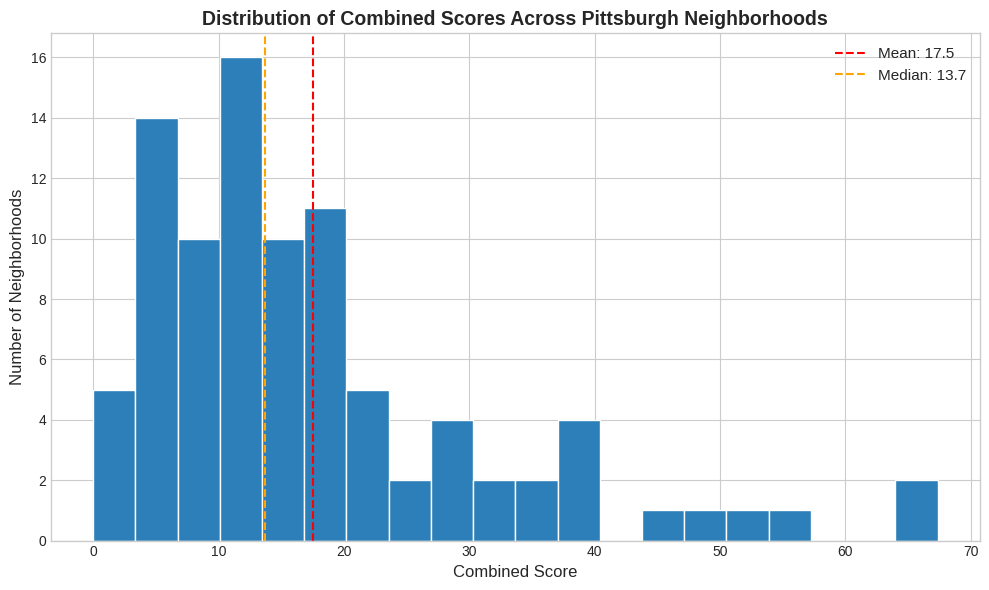

In [13]:
# Visualization 4: Distribution of combined scores
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(merged['Combined_Score'].dropna(), bins=20, color='#2c7fb8', edgecolor='white')
ax.axvline(merged['Combined_Score'].mean(), color='red', linestyle='--', 
           label=f"Mean: {merged['Combined_Score'].mean():.1f}")
ax.axvline(merged['Combined_Score'].median(), color='orange', linestyle='--', 
           label=f"Median: {merged['Combined_Score'].median():.1f}")

ax.set_xlabel('Combined Score', fontsize=12)
ax.set_ylabel('Number of Neighborhoods', fontsize=12)
ax.set_title('Distribution of Combined Scores Across Pittsburgh Neighborhoods', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## Step 8: Summary Statistics

In [14]:
# Summary statistics for the combined score. Total summary
print("Combined Score Statistics:")
print(f"  Mean:   {merged['Combined_Score'].mean():.2f}")
print(f"  Median: {merged['Combined_Score'].median():.2f}")
print(f"  Std Dev: {merged['Combined_Score'].std():.2f}")
print(f"  Min:    {merged['Combined_Score'].min():.2f}")
print(f"  Max:    {merged['Combined_Score'].max():.2f}")
print(f"\nTotal neighborhoods ranked: {len(merged)}")

Combined Score Statistics:
  Mean:   17.54
  Median: 13.69
  Std Dev: 14.17
  Min:    0.00
  Max:    67.35

Total neighborhoods ranked: 91


## Analysis: The Best Neighborhood in Pittsburgh

Based on our combined metric, **the best neighborhood in Pittsburgh depends on the final scores above**, but we can already draw several insights from how the sub-metrics interact:

**Here are some of the key findings from combining the metrics:**

1. No single neighborhood dominates both metrics. The neighborhoods that score highest on education (Central Oakland, North Oakland, Bluff) are university-adjacent areas that tend to have fewer green spaces. Meanwhile, the neighborhoods with the most green spaces (East Liberty, Beechview, South Side Slopes) have moderate or lower education rates. This means the combined metric rewards neighborhoods that are well-rounded rather than extreme on one dimension or one area.

2. **The combined ranking tells a different story than either metric alone.** My individual analysis pointed to Central Oakland as the best with a 78.6% higher education rate, and Sadia's pointed to East Liberty, with 12 green spaces. By combining them, we get a more balanced picture that avoids picking a neighborhood that's great in one way but lacking in another.

3. **The stacked bar chart reveals what drives each neighborhood's ranking.** Some neighborhoods earn their combined score mostly through education, others mostly through green space, and the top-ranked ones tend to have meaningful contributions from both.

4. **The scatter plot shows the tradeoff.** Most neighborhoods cluster in the lower left (low on both), while a few stand out on one axis or the other. Neighborhoods in the upper-right quadrant, scoring above the median on both education and green space, are the true standouts.

5. **Small-population neighborhoods remain an issue.** As I (Kevin) noted in my individual analysis, places like South Shore (12 residents) and Chateau (3 residents) produce unreliable rates. These should be taken with a grain of salt in the ranking.

## Conclusions

### Kevin's Conclusion

Looking at the combined results, I think merging education and green space into one metric gives a much more realistic picture of neighborhood quality than either metric alone. My individual analysis showed Central Oakland as the clear winner, but that's almost entirely because it's packed with Pitt students. It's not necessarily a great place to live. By factoring in green spaces, the combined ranking pushes neighborhoods that are more well-rounded toward the top.

My personal favorite neighborhood is still Shadyside. It has a solid higher education rate (32%, ranked 10th) and while it didn't lead in green spaces, it's a walkable neighborhood with good restaurants and shops. The data-driven "best" and my personal "best" are different, which makes sense. Data captures measurable things, but can't capture the feel of walking down Walnut Street on a nice day. With that said, I think this project shows that combining multiple metrics gets you closer to a meaningful answer than relying on any single number.

### Sadia's Conclusion

After seeing the combined results, I find it interesting how different the answer is compared to my individual analysis. On its own, East Liberty stood out as the clear winner for green spaces with 12 parks. But in the combined ranking, it may have shifted depending on how it scored on education.

This reinforces the idea that no single metric can fully define what makes a neighborhood "the best." Green spaces are important for quality of life. They encourage physical activity, reduce stress, and bring communities together. But they are only one piece of the puzzle. Combining green space with education gives a more complete picture.

My personal favorite neighborhood is one where I feel safe and where there are things to do outdoors. The data-driven result may or may not match that, and that's okay. The goal of this project was to practice making a data-driven argument, and I think our combined metric does that well even though real-world decisions involve factors that are harder to quantify, like how a neighborhood feels or whether your friends live there.

## Final stage, Export Final Rankings

In [15]:
# Save the final combined rankings to CSV
final_export = merged[['Combined_Rank', 'Neighborhood', 'Combined_Score', 
                        'Higher_Ed_Rate_Pct', 'Green_Space_Count',
                        'Education_Score', 'GreenSpace_Score']].copy()

final_export.to_csv('final_combined_rankings.csv', index=False)
print("Final rankings saved to 'final_combined_rankings.csv'")

Final rankings saved to 'final_combined_rankings.csv'
